In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/riyak/OneDrive/Documents/job-market-intelligence-project/data/processed/job_market_dataset.csv")

df.head()

,job_id,job_title,company,location_display,location_area,description,created,contract_time,contract_type,salary_min,...,work_year,experience_level,employment_type,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,4811316526,machine learning researcher,Quanta Search,"New York City, New York","['US', 'New York', 'New York City']",Our client is a process driven investment mana...,2024-08-05T11:05:19Z,NaN,NaN,147795.31,...,2024,SE,FT,250800,USD,250800,US,0,US,M
1,4811316526,machine learning researcher,Quanta Search,"New York City, New York","['US', 'New York', 'New York City']",Our client is a process driven investment mana...,2024-08-05T11:05:19Z,NaN,NaN,147795.31,...,2023,MI,FT,224400,USD,224400,US,0,US,M
2,4811316526,machine learning researcher,Quanta Search,"New York City, New York","['US', 'New York', 'New York City']",Our client is a process driven investment mana...,2024-08-05T11:05:19Z,NaN,NaN,147795.31,...,2023,SE,FT,212000,USD,212000,US,0,US,M
3,4811316526,machine learning researcher,Quanta Search,"New York City, New York","['US', 'New York', 'New York City']",Our client is a process driven investment mana...,2024-08-05T11:05:19Z,NaN,NaN,147795.31,...,2024,MI,FT,210000,USD,210000,US,0,US,M
4,4811316526,machine learning researcher,Quanta Search,"New York City, New York","['US', 'New York', 'New York City']",Our client is a process driven investment mana...,2024-08-05T11:05:19Z,NaN,NaN,147795.31,...,2023,MI,FT,210000,USD,210000,US,0,US,S


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35627 entries, 0 to 35626
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               35627 non-null  int64  
 1   job_title            35627 non-null  object 
 2   company              35627 non-null  object 
 3   location_display     35627 non-null  object 
 4   location_area        35627 non-null  object 
 5   description          35627 non-null  object 
 6   created              35627 non-null  object 
 7   contract_time        21335 non-null  object 
 8   contract_type        5220 non-null   object 
 9   salary_min           35627 non-null  float64
 10  salary_max           35627 non-null  float64
 11  salary_is_predicted  35627 non-null  int64  
 12  redirect_url         35627 non-null  object 
 13  category_label       35627 non-null  object 
 14  category_tag         35627 non-null  object 
 15  latitude             29027 non-null 

,job_id,salary_min,salary_max,salary_is_predicted,latitude,longitude,work_year,salary,salary_in_usd,remote_ratio
count,3.562700e+04,35627.000000,35627.000000,35627.000000,29027.000000,29027.000000,35627.000000,3.562700e+04,35627.000000,35627.000000
mean,5.381422e+09,97880.357747,98764.518636,0.912847,45.412129,-51.830593,2023.109748,1.677621e+05,156429.467286,32.800966
std,9.838144e+07,42320.666812,42043.158597,0.282063,8.158851,46.810903,0.688643,3.758919e+05,64453.890448,46.611984
min,4.804404e+09,40481.860000,40481.860000,0.000000,28.077560,-122.120900,2020.000000,1.500000e+04,15000.000000,0.000000
25%,5.362758e+09,74870.450000,74870.450000,1.000000,38.893471,-93.269357,2023.000000,1.130000e+05,112200.000000,0.000000
50%,5.418086e+09,84817.980000,90000.000000,1.000000,44.983654,-73.222446,2023.000000,1.500000e+05,150000.000000,0.000000
75%,5.443301e+09,135125.360000,135125.360000,1.000000,53.480701,-1.549120,2024.000000,1.945475e+05,193500.000000,100.000000
max,5.445436e+09,202576.720000,202576.720000,1.000000,53.957699,-0.139134,2024.000000,3.040000e+07,774000.000000,100.000000


Univariate Analysis

Salary Distribution

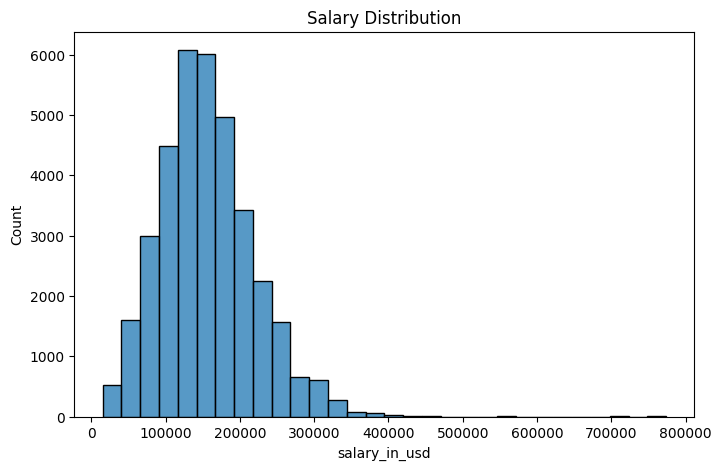

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary_in_usd"], bins=30)
plt.title("Salary Distribution")
plt.show()

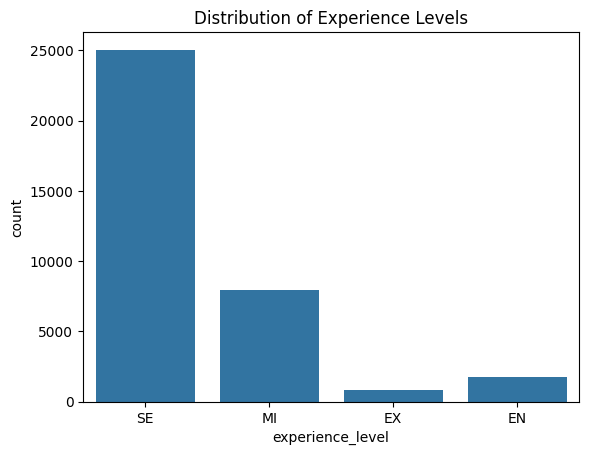

In [19]:
sns.countplot(x="experience_level", data=df)
plt.title("Distribution of Experience Levels")
plt.show()

Most data roles fall within a specific salary range.

Bivariate Analysis (Relationship Between Variables)

Salary vs Experience Level

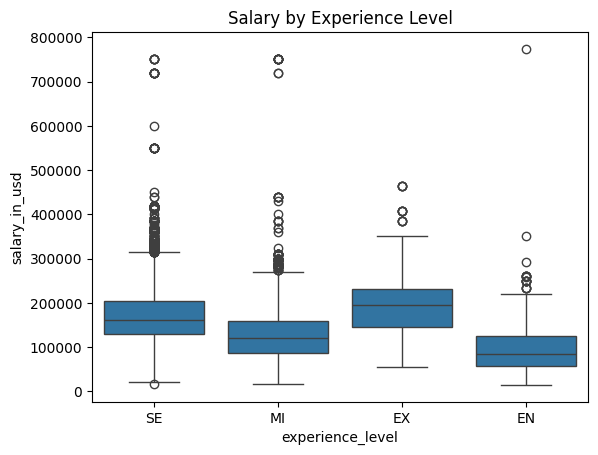

In [20]:
sns.boxplot(x="experience_level", y="salary_in_usd", data=df)
plt.title("Salary by Experience Level")
plt.show()

Salary increases significantly with experience.

Salary vs Company Size

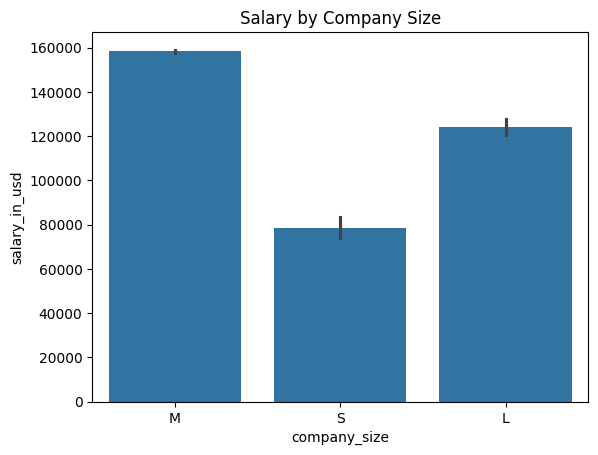

In [21]:
sns.barplot(x="company_size", y="salary_in_usd", data=df)
plt.title("Salary by Company Size")
plt.show()

Larger companies often pay higher salaries.

Remote Work Distribution

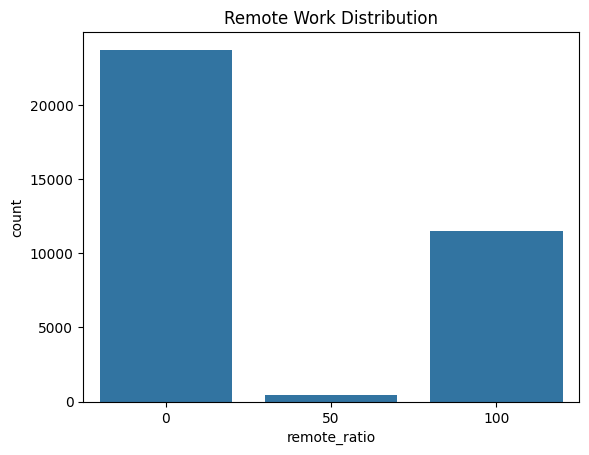

In [22]:
sns.countplot(x="remote_ratio", data=df)
plt.title("Remote Work Distribution")
plt.show()

 Top Paying Job Roles

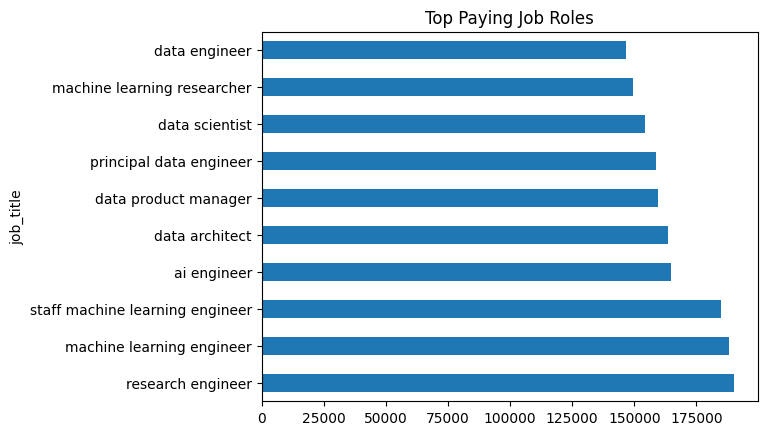

In [23]:
top_roles = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

top_roles.plot(kind="barh")
plt.title("Top Paying Job Roles")
plt.show()

Certain specialized roles have significantly higher salaries.

Company Location Analysis

In [24]:
df["company_location"].value_counts().head(10)


company_location
US    31396
GB     1472
CA      954
ES      370
DE      192
FR      147
AU      104
IN      102
NL       68
LT       56
Name: count, dtype: int64

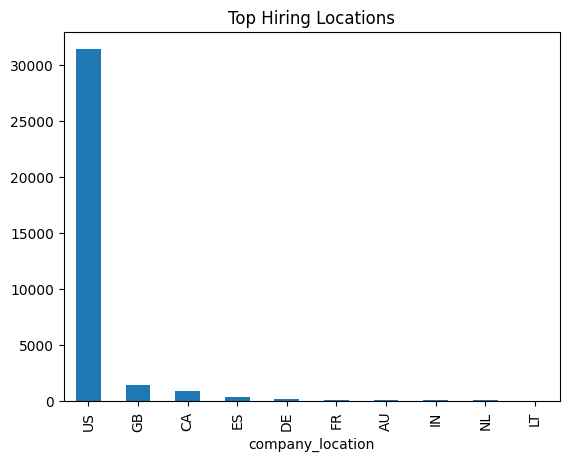

In [25]:
df["company_location"].value_counts().head(10).plot(kind="bar")
plt.title("Top Hiring Locations")
plt.show()

 Correlation Analysis

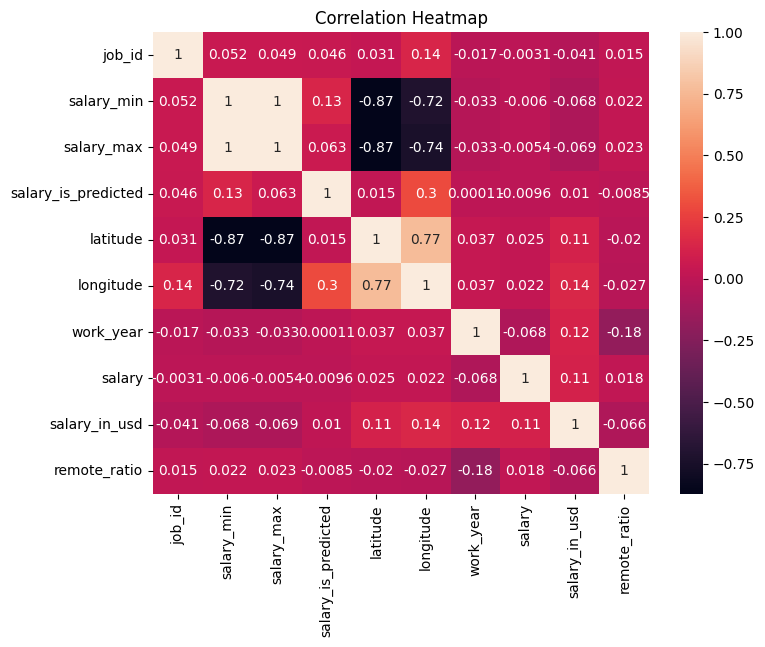

In [26]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
df.to_csv("C:/Users/riyak/OneDrive/Documents/job-market-intelligence-project/data/processed/final_job_market_dataset.csv", index=False)